# Camada Ouro — Modelo 2: Previsão de Compra (30 dias)

**Dependências:** `03_Camada_Ouro_EDA.ipynb` · `04_Camada_Ouro_Segmentacao.ipynb`

**Input:** `prata/clickbus_treino.parquet` · `prata/clickbus_val.parquet` · `ouro/df_cliente.parquet` · `ouro/df_cliente_clusterizado.parquet`

**Output:** `ouro/df_modelo_classificacao.parquet` · `ouro/xgboost_30d.pkl`

## Problema de negócio

Dado o histórico de comportamento de um cliente até a data de corte do treino, ele realizará alguma compra nos próximos 30 dias?

- **Target = 1** — comprou na janela de 30 dias após o corte
- **Target = 0** — não comprou nessa janela

## Decisões metodológicas

| Decisão | Escolha | Motivo |
|---|---|---|
| Origem do target | `df_val` filtrado a 30 dias | Nunca `df_treino` — evita leakage temporal |
| Encoding do cluster | `pd.get_dummies` | Clusters são nominais, não ordinais — `LabelEncoder` assumiria ordenação inexistente |
| Balanceamento | Sampler dentro do `ImbPipeline` | SMOTE aplicado fora do CV contamina os folds de validação interna |
| Algoritmo | XGBoost | Robusto em dados tabulares, captura interações não-lineares sem escalonamento |
| Métrica principal | AUC-PR | AUC-ROC é otimista em dados desbalanceados — PR foca na classe positiva |
| Threshold | Máximo do F1 na curva | Padrão 0.5 ignora a assimetria entre FP (campanha desperdiçada) e FN (venda perdida) |

In [2]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay,
    f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay,
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline      import Pipeline as ImbPipeline

import xgboost as xgb
import shap
import time
import joblib

!git clone https://github.com/vsmacedo-datafinance/Challenge_ClickBus_FIAP_2025.git 2>/dev/null
sys.path.append('/content/Challenge_ClickBus_FIAP_2025')

drive.mount('/content/drive')

sns.set_theme(style='whitegrid')

DRIVE_BASE   = "/content/drive/MyDrive/Portifólio DS Vini/Challenge_ClickBus_2025/data"

JANELA_DIAS  = 30
RANDOM_STATE = 42
MESES_ALTA = [1, 7, 12]
MESES_FERIAS = [1, 7, 11, 12]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df_treino = pd.read_parquet(f"{DRIVE_BASE}/prata/clickbus_treino.parquet")
df_val = pd.read_parquet(f"{DRIVE_BASE}/prata/clickbus_val.parquet")

df_cliente = pd.read_parquet(f"{DRIVE_BASE}/ouro/df_cliente.parquet")
df_cliente_clusterizado = pd.read_parquet(f"{DRIVE_BASE}/ouro/df_cliente_clusterizado.parquet")

## Criação de features

In [4]:
from src.utils import analisar_feriados_projeto

# novas features
df_treino['compra_mes_alta'] = df_treino['mes'].isin(MESES_ALTA).astype(int)

sazon = (
    df_treino
    .groupby('id_cliente')
    .agg(compras_alta=('compra_mes_alta', 'sum'), total=('gmv_success', 'count'))
    .assign(sazonalidade_score=lambda x: x['compras_alta'] / x['total'])
    .reset_index()[['id_cliente', 'sazonalidade_score']]
    )

df_treino['mes_ferias'] = df_treino['mes'].isin(MESES_FERIAS).astype(int)
ferias = (
  df_treino
  .groupby('id_cliente')
  .agg(compras_ferias=('mes_ferias', 'sum'), total_f=('gmv_success', 'count'))
  .assign(prop_ferias=lambda x: x['compras_ferias'] / x['total_f'])
  .reset_index()[['id_cliente', 'prop_ferias']]
    )

mes_ult = (
  df_treino
  .groupby('id_cliente')['data_compra']
  .max()
  .dt.month
  .reset_index()
  .rename(columns={'data_compra': 'mes_ultima_compra'})
    )

intervalo = (
  df_treino
  .sort_values(['id_cliente', 'data_compra'])
  .assign(dias_prev=lambda x:
  x.groupby('id_cliente')['data_compra'].diff().dt.days)
  .groupby('id_cliente')['dias_prev']
  .mean()
  .fillna(9999)
  .reset_index()
  .rename(columns={'dias_prev': 'intervalo_medio_dias'})
    )

_, _, dias_ate_feriado = analisar_feriados_projeto(df_treino, data_corte=df_treino['data_compra'].max())

df_cliente = (
  df_cliente
  .merge(sazon,    on='id_cliente', how='left')
  .merge(ferias,   on='id_cliente', how='left')
  .merge(mes_ult,  on='id_cliente', how='left')
  .merge(intervalo, on='id_cliente', how='left')
  .merge(df_cliente_clusterizado[['id_cliente', 'cluster']], on='id_cliente', how='left')
    )

df_cliente['dias_ate_proximo_feriado'] = dias_ate_feriado
df_cliente['intervalo_medio_dias'] = df_cliente['intervalo_medio_dias'].fillna(9999)
df_cliente['sazonalidade_score'] = df_cliente['sazonalidade_score'].fillna(0)
df_cliente['prop_ferias'] = df_cliente['prop_ferias'].fillna(0)

**Novas features criadas sobre `df_treino`:**

| Feature | O que captura |
|---|---|
| `sazonalidade_score` | Proporção de compras em meses de alta demanda (jan, jul, dez). Proxy de sensibilidade sazonal. |
| `prop_ferias` | Proporção de compras em meses de férias escolares. Complementa `prop_feriado` com granularidade mensal. |
| `mes_ultima_compra` | Mês da última compra — onde no calendário o cliente está mais ativo. |
| `intervalo_medio_dias` | Ritmo de compra: média de dias entre transações consecutivas. Clientes sem histórico de recorrência recebem 9999 — sinal explícito de one-shot. |
| `dias_ate_proximo_feriado` | Constante para todos os clientes — captura o contexto de curto prazo da demanda. |

Todas calculadas exclusivamente sobre `df_treino` e mergeadas via `id_cliente`. O `df_val` não é tocado nesta etapa.

In [5]:
print(f"\ndf_cliente shape após merge do cluster: {df_cliente.shape}")


df_cliente shape após merge do cluster: (462800, 27)


## Criação Target

In [6]:
data_ref = df_treino['data_compra'].max()
data_limite = data_ref + pd.Timedelta(days=JANELA_DIAS)

compradores = set(
    df_val
    .loc[df_val['data_compra'] <= data_limite, 'id_cliente']
    .unique()
)

df_modelo = df_cliente.copy()
df_modelo['target'] = df_modelo['id_cliente'].isin(compradores).astype(int)

n_total = len(df_modelo)
n_pos   = df_modelo['target'].sum()
n_neg   = n_total - n_pos
taxa_conversao = (n_pos / n_total) * 100

print(f"Total de clientes: {n_total}")
print(f"Compraram na janela 30d (Target=1): {n_pos} ({taxa_conversao:.2f}%)")
print(f"Não compraram (Target=0): {n_neg}")

Total de clientes: 462800
Compraram na janela 30d (Target=1): 18079 (3.91%)
Não compraram (Target=0): 444721


**Lógica temporal do target:**

`data_ref` é o último dia do treino — o "hoje" do modelo. Tudo que ele sabe aprendeu antes dessa data. `data_limite` é o horizonte de previsão — 30 dias à frente.

O target é construído verificando quem aparece em `df_val` dentro dessa janela. O filtro `<= data_limite` é obrigatório: sem ele, qualquer compra em `df_val` (que cobre ~6 meses) seria contada como positiva, inflando a taxa de ~4% para ~40% e tornando o problema trivialmente fácil de resolver — mas irreal.

A taxa de ~4% é o número correto para recompra em 30 dias no transporte rodoviário brasileiro. É um problema genuinamente difícil, e é exatamente por isso que as estratégias de balanceamento importam.

In [7]:
df_modelo = df_modelo.drop(columns=[
    'id_cliente',
    'primeira_compra',
    'ultima_compra',
    'periodo_covid_max',
    'gmv_total_log',
    'total_compras_log',
    'n_destinos_distintos_log',
    'pop_trecho_media_log',
    'tempo_vida_dias_log',
    'recencia_dias_log'
])

**Por que as versões `_log` foram removidas?**

As transformações `log1p` foram criadas na EDA para o K-Means, que usa distância euclidiana e é sensível à escala. Para o XGBoost — baseado em árvores de decisão — a escala não importa: o algoritmo encontra os mesmos splits em `gmv_total` e em `log1p(gmv_total)`. Manter as duas versões seria redundância pura, aumentando dimensionalidade sem ganho preditivo.

As features de comportamento (`prop_feriado`, `score_fidelidade`, `prop_fim_semana`) não têm versão log porque sua escala já é [0, 1].

In [8]:
df_modelo = pd.get_dummies(df_modelo, columns=['cluster'], drop_first=False)

X = df_modelo.drop(columns=['target'])
y = df_modelo['target']

X_train, X_eval, y_train, y_eval = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Dimensão Treino    : X={X_train.shape}, y={y_train.shape}")
print(f"Dimensão Avaliação : X={X_eval.shape}, y={y_eval.shape}")

Dimensão Treino    : X=(370240, 21), y=(370240,)
Dimensão Avaliação : X=(92560, 21), y=(92560,)


**Por que split estratificado e não temporal neste ponto?**

`df_modelo` tem uma linha por cliente, todos agregados até o mesmo ponto no tempo (`data_ref`). Não há sequência temporal entre clientes — apenas entre transações, que já foi respeitada na Prata com o split out-of-time.

`stratify=y` garante que a proporção de compradores (~4%) seja preservada em treino e avaliação. Sem isso, o split aleatório poderia concentrar positivos em um dos lados por acaso, comprometendo a avaliação.

## Resultados

In [9]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Ratio de desbalanceamento: {ratio:.1f}:1\n")

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

param_grid = {
    'xgb__n_estimators'    : [200, 300, 400],
    'xgb__max_depth'       : [4, 5, 6],
    'xgb__learning_rate'   : [0.01, 0.05, 0.1],
    'xgb__subsample'       : [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0],
}

# pipelines
experimentos = {
    'Undersampling': ImbPipeline([
        ('bal', RandomUnderSampler(random_state=RANDOM_STATE)),
        ('xgb', xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1))
    ]),

    'SMOTE': ImbPipeline([
        ('bal', SMOTE(random_state=RANDOM_STATE)),
        ('xgb', xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1))
    ]),

    'Scale_Pos_Weight': ImbPipeline([
        ('xgb', xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1, scale_pos_weight=ratio))
    ])
}

resultados = []

for nome, pipeline in experimentos.items():
    print(f"[{nome}] Iniciando Randomized Search (10 iterações)...")
    start_time = time.time()

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grid,
        n_iter=10,
        scoring='average_precision',
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1
    )
    search.fit(X_train, y_train)
    melhor_modelo = search.best_estimator_

    y_pred = melhor_modelo.predict(X_eval)
    y_proba = melhor_modelo.predict_proba(X_eval)[:, 1]

    resultados.append({
        'Abordagem'      : nome,
        'PR-AUC'         : average_precision_score(y_eval, y_proba),
        'ROC-AUC'        : roc_auc_score(y_eval, y_proba),
        'Recall'         : recall_score(y_eval, y_pred),
        'Precision'      : precision_score(y_eval, y_pred, zero_division=0),
        'F1-Score'       : f1_score(y_eval, y_pred),
        'Melhores Params': search.best_params_,
        'Tempo (s)'      : round(time.time() - start_time, 1),

        '_modelo'        : melhor_modelo,
        '_y_prob'        : y_proba,
        '_y_pred'        : y_pred,
    })

df_resultados = pd.DataFrame(resultados).set_index('Abordagem')

Ratio de desbalanceamento: 24.6:1

[Undersampling] Iniciando Randomized Search (10 iterações)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[SMOTE] Iniciando Randomized Search (10 iterações)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[Scale_Pos_Weight] Iniciando Randomized Search (10 iterações)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [10]:
df_resultados = (
    pd.DataFrame(resultados)
    .set_index('Abordagem')
    .drop(columns=['_modelo', '_y_prob', '_y_pred'])
)

display(
    df_resultados
    .nlargest(1, 'PR-AUC')
    .style
    .format({c: '{:.4f}' for c in ['PR-AUC','ROC-AUC','Recall','Precision','F1-Score']})
)

# melhor resultado pelo índice do PR-AUC
melhor = max(resultados, key=lambda x: x['PR-AUC'])

melhor_nome  = melhor['Abordagem']
modelo_final = melhor['_modelo']
y_prob_final = melhor['_y_prob']
y_pred_final = melhor['_y_pred']

,PR-AUC,ROC-AUC,Recall,Precision,F1-Score,Melhores Params,Tempo (s)
Abordagem,,,,,,,
Scale_Pos_Weight,0.2663,0.8375,0.7282,0.1229,0.2102,"{'xgb__subsample': 0.8, 'xgb__n_estimators': 400, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.01, 'xgb__colsample_bytree': 0.8}",334.200000


**Leitura da tabela:**

A coluna de referência é **PR-AUC** — mede a área sob a curva Precision-Recall, que é a métrica mais honesta para dados desbalanceados porque o baseline aleatório é proporcional à taxa real de positivos (~4%), não fixo em 0.5 como no ROC.

O trade-off entre as estratégias é sempre o mesmo: aumentar recall (encontrar mais compradores reais) reduz precision (mais falsos positivos). No contexto de campanha de Growth:

- **FN** (comprador que escapou) = venda perdida — custo mais alto
- **FP** (não comprador ativado) = custo de campanha desperdiçado — custo menor

Por isso recall alto é geralmente preferível, desde que a precision não caia a ponto de tornar a campanha inviável financeiramente.

CALIBRAÇÃO DE THRESHOLD
Threshold ótimo (max F1): 0.79
F1-Score                : 0.3250
Precision               : 0.2734
Recall                  : 0.4007


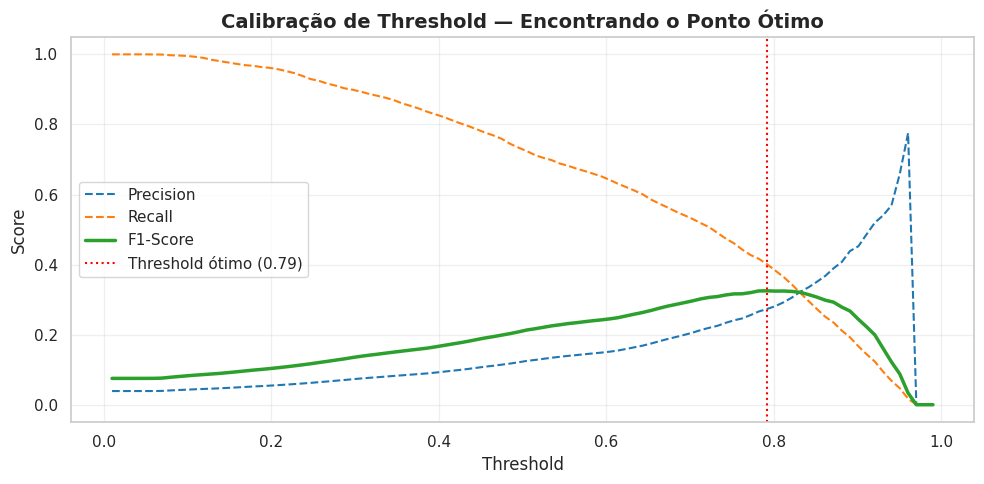

In [11]:
thresholds = np.linspace(0.01, 0.99, 100)
f1_scores, precisions, recalls = [], [], []

for t in thresholds:
    y_pred_t = (y_prob_final >= t).astype(int)
    f1_scores.append(f1_score(y_eval, y_pred_t, zero_division=0))
    precisions.append(precision_score(y_eval, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_eval, y_pred_t, zero_division=0))

melhor_idx_thresh = int(np.argmax(f1_scores))
best_threshold    = thresholds[melhor_idx_thresh]

print("=" * 45)
print("CALIBRAÇÃO DE THRESHOLD")
print("=" * 45)
print(f"Threshold ótimo (max F1): {best_threshold:.2f}")
print(f"F1-Score                : {f1_scores[melhor_idx_thresh]:.4f}")
print(f"Precision               : {precisions[melhor_idx_thresh]:.4f}")
print(f"Recall                  : {recalls[melhor_idx_thresh]:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions, label='Precision', color='#1f77b4', linestyle='--')
plt.plot(thresholds, recalls,    label='Recall',    color='#ff7f0e', linestyle='--')
plt.plot(thresholds, f1_scores,  label='F1-Score',  color='#2ca02c', linewidth=2.5)
plt.axvline(best_threshold, color='red', linestyle=':', label=f'Threshold ótimo ({best_threshold:.2f})')
plt.title('Calibração de Threshold — Encontrando o Ponto Ótimo', fontsize=14, fontweight='bold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

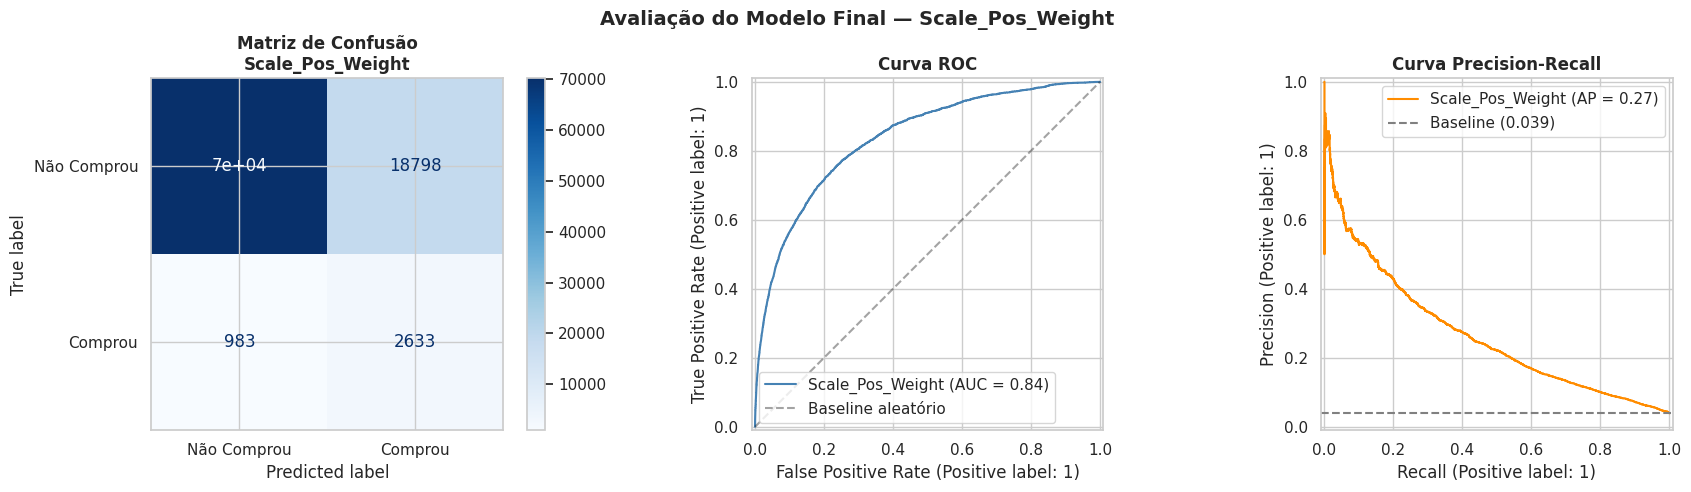

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(
    y_eval, y_pred_final,
    display_labels=['Não Comprou', 'Comprou'],
    cmap='Blues',
    ax=axes[0],
)
axes[0].set_title(f'Matriz de Confusão\n{melhor_nome}', fontweight='bold')

RocCurveDisplay.from_predictions(
    y_eval, y_prob_final,
    ax=axes[1],
    color='steelblue',
    name=melhor_nome,
)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Baseline aleatório')
axes[1].set_title('Curva ROC', fontweight='bold')
axes[1].legend()

PrecisionRecallDisplay.from_predictions(
    y_eval, y_prob_final,
    ax=axes[2],
    color='darkorange',
    name=melhor_nome,
)
axes[2].axhline(
    y_eval.mean(),
    linestyle='--', color='gray',
    label=f'Baseline ({y_eval.mean():.3f})',
)
axes[2].set_title('Curva Precision-Recall', fontweight='bold')
axes[2].legend()

plt.suptitle(f'Avaliação do Modelo Final — {melhor_nome}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Leitura dos gráficos:**

A **Matriz de Confusão** mostra o volume real de cada tipo de erro. Os Falsos Negativos (linha "Comprou", coluna "Não Comprou") são os compradores que o modelo não conseguiu identificar — cada um representa uma venda não ativada.

A **Curva ROC** mede a capacidade geral de separação entre classes. A diagonal é o baseline aleatório. Uma curva que se aproxima do canto superior esquerdo indica que o modelo discrimina bem.

A **Curva Precision-Recall** é a mais informativa aqui. A linha horizontal tracejada é o baseline aleatório — equivalente a prever sempre positivo. Qualquer ponto acima dessa linha representa ganho real sobre o acaso. A área sob essa curva (AUC-PR) é a métrica principal do projeto.

In [13]:
print("=" * 55)
print(f"  MÉTRICAS DETALHADAS — {melhor_nome}")
print("=" * 55)
print(f"  AUC-ROC : {melhor['ROC-AUC']:.4f}")
print(f"  AUC-PR  : {melhor['PR-AUC']:.4f}  (baseline: {y_eval.mean():.4f})")
print(f"  F1      : {melhor['F1-Score']:.4f}")
print("=" * 55)
print(classification_report(
    y_eval, y_pred_final,
    target_names=['Não Comprou', 'Comprou'],
))

  MÉTRICAS DETALHADAS — Scale_Pos_Weight
  AUC-ROC : 0.8375
  AUC-PR  : 0.2663  (baseline: 0.0391)
  F1      : 0.2102
              precision    recall  f1-score   support

 Não Comprou       0.99      0.79      0.88     88944
     Comprou       0.12      0.73      0.21      3616

    accuracy                           0.79     92560
   macro avg       0.55      0.76      0.54     92560
weighted avg       0.95      0.79      0.85     92560



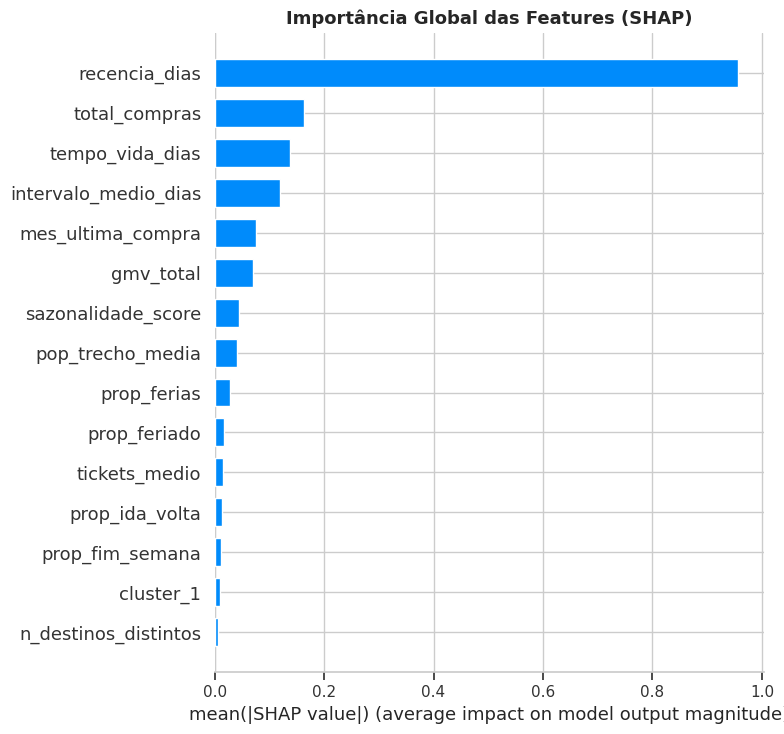

In [14]:
explainer   = shap.TreeExplainer(modelo_final.named_steps['xgb'])
shap_values = explainer.shap_values(X_eval)

shap.summary_plot(shap_values, X_eval, plot_type='bar', max_display=15, show=False)
plt.title('Importância Global das Features (SHAP)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

**Interpretação econômica do SHAP:**

As features com maior importância global revelam o que de fato diferencia um cliente propenso a recomprar de um que não vai. Na teoria do consumidor, a decisão de repetir uma compra é função do valor percebido na experiência anterior, da urgência (feriado próximo) e do custo de busca por alternativas (fidelidade à empresa).

Clientes com `recencia_dias` baixo (compraram recentemente) e `intervalo_medio_dias` baixo (ritmo de compra frequente) tendem a ter SHAP positivo — confirmam o padrão esperado de que comportamento passado prediz comportamento futuro. O `score_fidelidade` alto também contribui positivamente: clientes leais a uma operadora têm menor custo de decisão na próxima compra.

In [15]:
os.makedirs(f"{DRIVE_BASE}/ouro", exist_ok=True)

# modelo serializado
joblib.dump(modelo_final, f"{DRIVE_BASE}/ouro/xgboost_30d.pkl")

df_saida = df_modelo[[]].copy()
df_saida['id_cliente']     = df_cliente['id_cliente'].values
df_saida['cluster']        = df_cliente['cluster'].values
df_saida['target']         = y.values
df_saida['prob_compra_30d'] = modelo_final.predict_proba(X)[:, 1]
df_saida['pred_compra_30d'] = (df_saida['prob_compra_30d'] >= best_threshold).astype(int)

df_saida.to_parquet(f"{DRIVE_BASE}/ouro/df_modelo_classificacao.parquet", index=False)

print(f"Modelo salvo        : ouro/xgboost_30d.pkl")
print(f"Predições salvas    : ouro/df_modelo_classificacao.parquet")
print(f"Threshold utilizado : {best_threshold:.2f}")
print(f"Clientes totais     : {len(df_saida):,}")
print(f"Ativados (pred=1)   : {df_saida['pred_compra_30d'].sum():,}  ({df_saida['pred_compra_30d'].mean():.1%})")

Modelo salvo        : ouro/xgboost_30d.pkl
Predições salvas    : ouro/df_modelo_classificacao.parquet
Threshold utilizado : 0.79
Clientes totais     : 462,800
Ativados (pred=1)   : 26,589  (5.7%)
